<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/notebooks/02_preprocessing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QPon Reviews — Preprocessing & EDA

| | |
|---|---|
| **Input** | `qpon_reviews_raw.csv` (4,638 reviews) |
| **Output** | `qpon_preprocessed.csv` |
| **Author** | Zeldano Shan Oeffie (5026231118) |

Full text preprocessing pipeline + exploratory data analysis on QPon app reviews.
Builds on the raw data collected in `01_scraping_tokenization.ipynb`.

In [1]:
!pip install PySastrawi wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 1. Load Raw Data

In [3]:
df = pd.read_csv('qpon_reviews_raw.csv')
print(f'{len(df):,} reviews loaded')
df.info()
df.head(3)

4,659 reviews loaded
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4659 entries, 0 to 4658
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4659 non-null   object
 1   userName              4659 non-null   object
 2   userImage             4659 non-null   object
 3   content               4659 non-null   object
 4   score                 4659 non-null   int64 
 5   thumbsUpCount         4659 non-null   int64 
 6   reviewCreatedVersion  3620 non-null   object
 7   at                    4659 non-null   object
 8   replyContent          2773 non-null   object
 9   repliedAt             2773 non-null   object
 10  appVersion            3620 non-null   object
dtypes: int64(2), object(9)
memory usage: 400.5+ KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7c3a5a5a-6a31-46e4-a4b0-43bab32fa565,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,keren,5,0,NaN,2026-03-09 12:50:13,NaN,NaN,NaN
1,c29f1115-c4fc-4558-bab7-c239b8063f55,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tukar vocer qpon saldo udah kepotong status be...,1,0,NaN,2026-03-09 10:43:06,NaN,NaN,NaN
2,1cde626a-2e6e-4981-b90c-02ac6f3e02b3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"promonya kurang masih mahal, murahan jga tiktok",1,0,NaN,2026-03-09 06:11:40,NaN,NaN,NaN


In [4]:
print('Nulls:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'Empty content: {df["content"].isna().sum()}')

Nulls:
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    1039
at                         0
replyContent            1886
repliedAt               1886
appVersion              1039
dtype: int64

Duplicates: 0
Empty content: 0


In [5]:
df = df.dropna(subset=['content']).reset_index(drop=True)
print(f'{len(df):,} reviews after dropping empty content')

4,659 reviews after dropping empty content


---
## 2. Text Preprocessing

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # urls
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # extra spaces
    return text

df['clean'] = df['content'].apply(clean_text)

# before vs after
for i in [0, 1, 2]:
    print(f'Before: {df["content"].iloc[i]}')
    print(f'After : {df["clean"].iloc[i]}\n')

Before: keren
After : keren

Before: tukar vocer qpon saldo udah kepotong status belum bayar, jadi 2x bayar... mohon ditindak lanjut biar gak ada yang seperti itu lagi
After : tukar vocer qpon saldo udah kepotong status belum bayar jadi x bayar mohon ditindak lanjut biar gak ada yang seperti itu lagi

Before: promonya kurang masih mahal, murahan jga tiktok
After : promonya kurang masih mahal murahan jga tiktok



In [7]:
df['tokens'] = df['clean'].apply(word_tokenize)

print('Example:')
print(df['tokens'].iloc[0])

Example:
['keren']


In [8]:
stop_id = set(stopwords.words('indonesian'))

# add common informal stopwords found in app reviews
custom_stop = {'nya', 'yg', 'ga', 'gak', 'gk', 'udah', 'aja', 'udh',
               'tp', 'tpi', 'dah', 'dong', 'sih', 'nih', 'bgt', 'banget',
               'kalo', 'klo', 'sm', 'lgsg', 'emang', 'tuh', 'bisa', 'juga'}
stop_all = stop_id | custom_stop

df['no_stop'] = df['tokens'].apply(lambda t: [w for w in t if w not in stop_all and len(w) > 1])

print(f'Stopwords: {len(stop_all)} total ({len(stop_id)} NLTK + {len(custom_stop)} custom)\n')
print('Before:', df['tokens'].iloc[0])
print('After :', df['no_stop'].iloc[0])

Stopwords: 778 total (757 NLTK + 24 custom)

Before: ['keren']
After : ['keren']


In [9]:
stemmer = StemmerFactory().create_stemmer()

df['stemmed'] = df['no_stop'].apply(lambda t: [stemmer.stem(w) for w in t])

print('Before:', df['no_stop'].iloc[0])
print('After :', df['stemmed'].iloc[0])

Before: ['keren']
After : ['keren']


In [10]:
df['processed'] = df['stemmed'].apply(' '.join)

# preview full pipeline
print('Raw    :', df['content'].iloc[5])
print('Clean  :', df['clean'].iloc[5])
print('Tokens :', df['tokens'].iloc[5])
print('NoStop :', df['no_stop'].iloc[5])
print('Stemmed:', df['stemmed'].iloc[5])
print('Final  :', df['processed'].iloc[5])

Raw    : sangat bagus aplikasi ini.. dan mudah di pahami..
Clean  : sangat bagus aplikasi ini dan mudah di pahami
Tokens : ['sangat', 'bagus', 'aplikasi', 'ini', 'dan', 'mudah', 'di', 'pahami']
NoStop : ['bagus', 'aplikasi', 'mudah', 'pahami']
Stemmed: ['bagus', 'aplikasi', 'mudah', 'paham']
Final  : bagus aplikasi mudah paham


---
## 3. Sentiment Labeling

In [11]:
def label_sentiment(score):
    if score <= 2: return 'negative'
    elif score == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['score'].apply(label_sentiment)

print(df['sentiment'].value_counts())
print(f'\n{df["sentiment"].value_counts(normalize=True).mul(100).round(1)}')

sentiment
negative    2315
positive    2175
neutral      169
Name: count, dtype: int64

sentiment
negative    49.7
positive    46.7
neutral      3.6
Name: proportion, dtype: float64


---
## 4. Exploratory Data Analysis

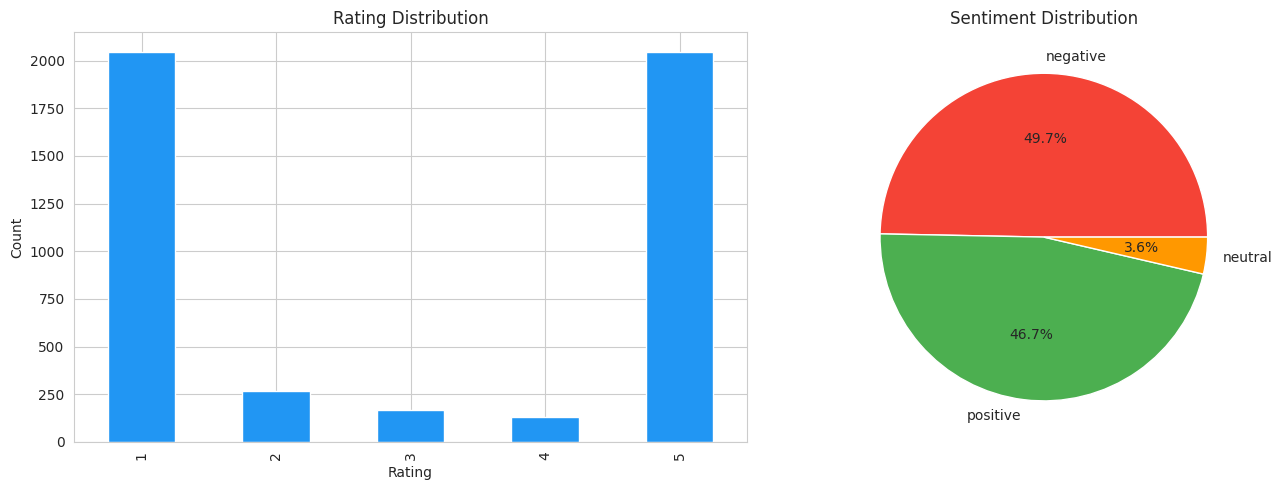

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# rating bar
df['score'].value_counts().sort_index().plot.bar(ax=axes[0], color='#2196F3')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# sentiment pie
colors = {'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336'}
sent_counts = df['sentiment'].value_counts()
sent_counts.plot.pie(ax=axes[1], autopct='%1.1f%%',
                     colors=[colors[s] for s in sent_counts.index])
axes[1].set_title('Sentiment Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

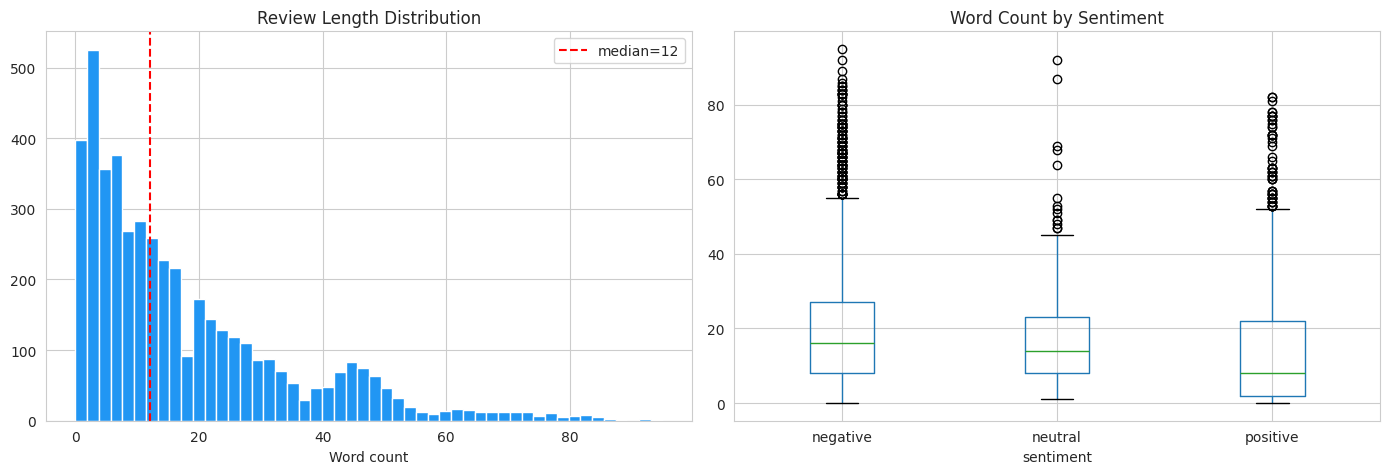

            count  mean   std  min  25%   50%   75%   max
sentiment                                                
negative   2315.0  20.4  17.1  0.0  8.0  16.0  27.0  95.0
neutral     169.0  18.2  16.0  1.0  8.0  14.0  23.0  92.0
positive   2175.0  15.0  16.6  0.0  2.0   8.0  22.0  82.0


In [13]:
df['word_count'] = df['tokens'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['word_count'].hist(bins=50, ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Review Length Distribution')
axes[0].set_xlabel('Word count')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'median={df["word_count"].median():.0f}')
axes[0].legend()

df.boxplot(column='word_count', by='sentiment', ax=axes[1])
axes[1].set_title('Word Count by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(df.groupby('sentiment')['word_count'].describe().round(1))

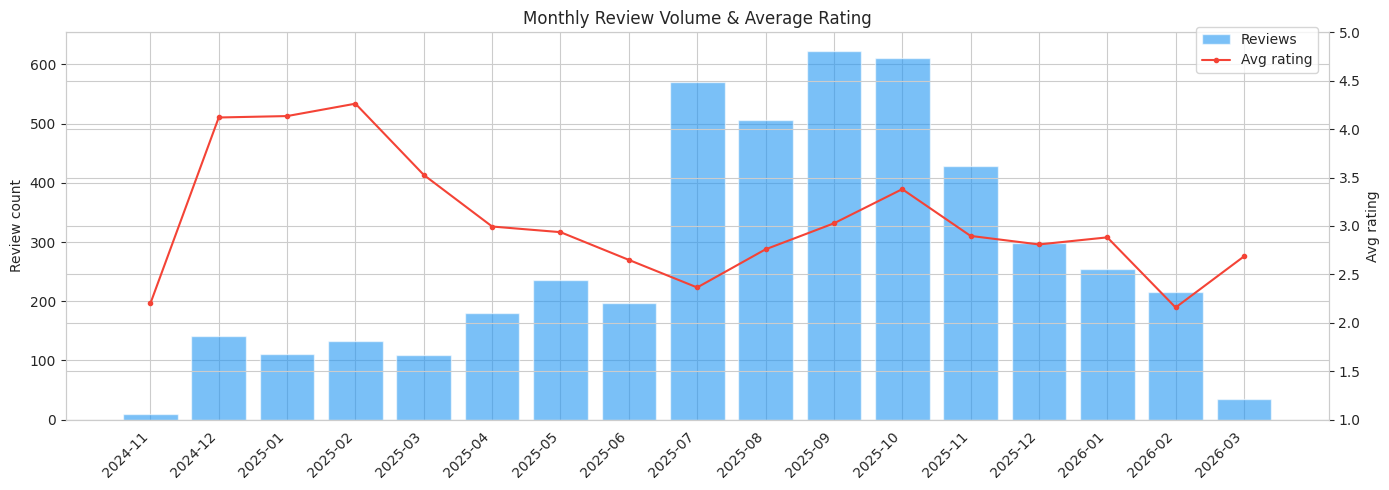

In [14]:
df['date'] = pd.to_datetime(df['at'])
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby('month').agg(
    reviews=('content', 'count'),
    avg_rating=('score', 'mean')
).reset_index()
monthly['month'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(range(len(monthly)), monthly['reviews'], color='#2196F3', alpha=0.6, label='Reviews')
ax1.set_ylabel('Review count')

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['avg_rating'], color='#F44336', marker='o', markersize=3, label='Avg rating')
ax2.set_ylabel('Avg rating')
ax2.set_ylim(1, 5)

# show every nth label to avoid clutter
n = max(1, len(monthly) // 12)
ax1.set_xticks(range(0, len(monthly), n))
ax1.set_xticklabels(monthly['month'].iloc[::n], rotation=45, ha='right')

ax1.set_title('Monthly Review Volume & Average Rating')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

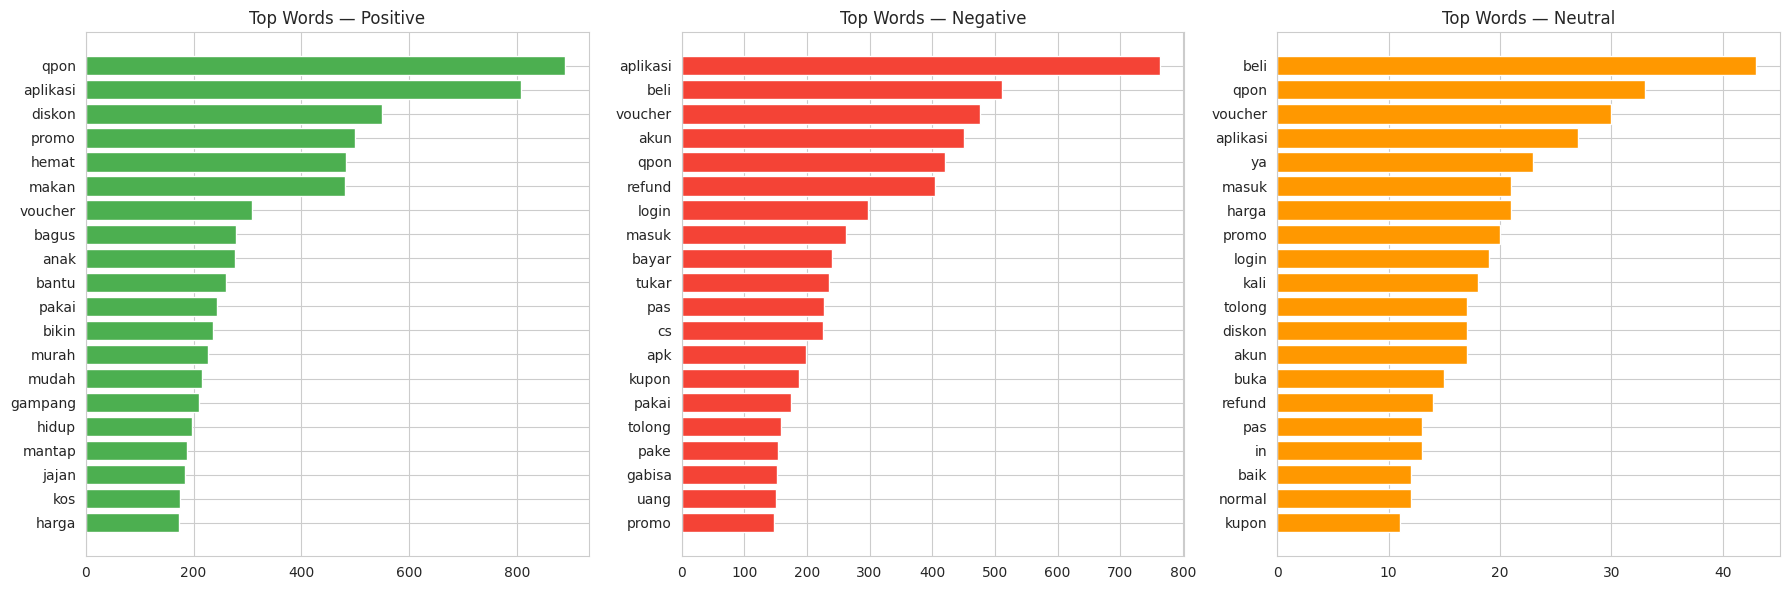

In [15]:
def top_words(series, n=20):
    all_w = []
    for tokens in series:
        if isinstance(tokens, list):
            all_w.extend(tokens)
    return Counter(all_w).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sent, color in zip(axes, ['positive', 'negative', 'neutral'],
                            ['#4CAF50', '#F44336', '#FF9800']):
    words = top_words(df[df['sentiment'] == sent]['stemmed'])
    ax.barh([w for w, _ in words][::-1], [c for _, c in words][::-1], color=color)
    ax.set_title(f'Top Words — {sent.title()}')

plt.tight_layout()
plt.show()

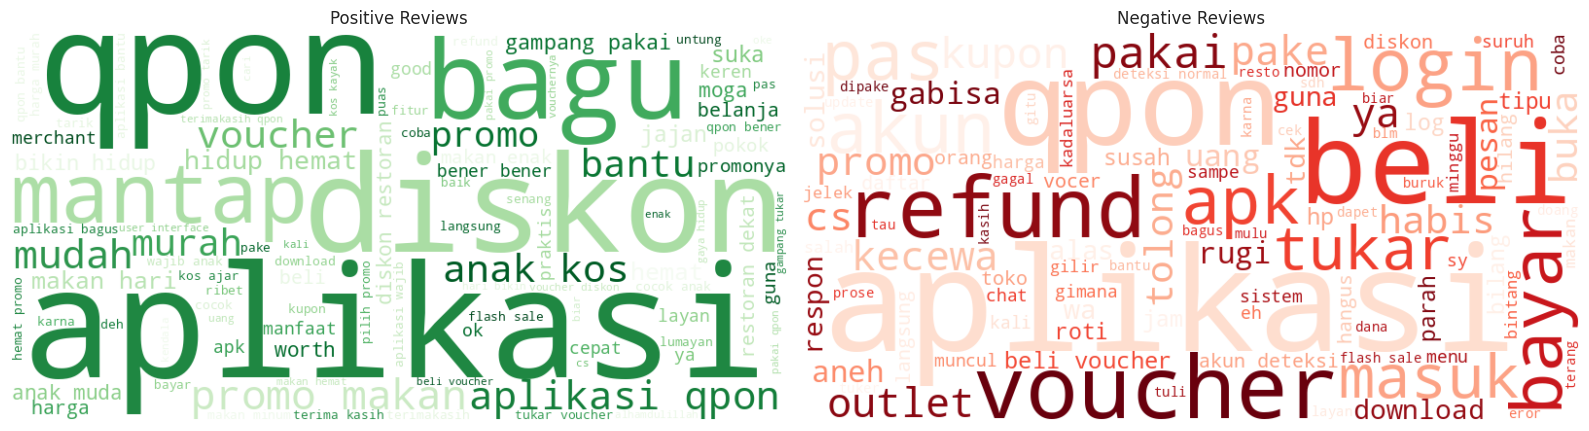

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sent, cmap in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['sentiment'] == sent]['processed'].dropna())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sent.title()} Reviews')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 5. Save Preprocessed Data

In [17]:
# keep useful columns
out = df[['content', 'score', 'at', 'clean', 'processed', 'sentiment']].copy()
out.to_csv('qpon_preprocessed.csv', index=False)
print(f'Saved {len(out):,} rows to qpon_preprocessed.csv')
out.head()

Saved 4,659 rows to qpon_preprocessed.csv


,content,score,at,clean,processed,sentiment
0,keren,5,2026-03-09 12:50:13,keren,keren,positive
1,tukar vocer qpon saldo udah kepotong status be...,1,2026-03-09 10:43:06,tukar vocer qpon saldo udah kepotong status be...,tukar vocer qpon saldo potong status bayar bay...,negative
2,"promonya kurang masih mahal, murahan jga tiktok",1,2026-03-09 06:11:40,promonya kurang masih mahal murahan jga tiktok,promonya mahal murah jga tiktok,negative
3,very good .. all in one..,5,2026-03-09 02:58:33,very good all in one,very good all in one,positive
4,"UNINSTALL AJA GUYS MAKIN LAMA MAKIN JELEK, MAK...",1,2026-03-09 01:43:27,uninstall aja guys makin lama makin jelek maki...,uninstall guys jelek aneh voucher rb besok che...,negative


---
## Summary

**Preprocessing pipeline:** lowercase → remove URLs/punctuation/numbers → tokenize → remove stopwords (NLTK + custom) → stem (Sastrawi)

**Sentiment labels:** based on rating — negative (1–2), neutral (3), positive (4–5)

**Key findings:**
- Heavily polarized: most reviews are either 1★ or 5★, very few in between
- Negative reviews tend to be longer (users explain their frustrations in more detail)
- Common positive terms: promo, cashback, murah, bagus
- Common negative terms: error, gagal, lambat, kecewa
